<a href="https://colab.research.google.com/github/Jayantsinghkhanna/UCS547-ACCELERATED-DATA-SCIENCE-LAB/blob/main/Assignmen_3_AcceleratedDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1 — CUDA C++ Vector Addition (N = 1024)

In [7]:
%%writefile vector_add.cu
#include <stdio.h>

__global__ void vectorAdd(float *A, float *B, float *C, int N)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N)
        C[i] = A[i] + B[i];
}

int main()
{
    int N = 1024;
    size_t size = N * sizeof(float);

    float *A, *B, *C;
    float *d_A, *d_B, *d_C;

    A = (float*)malloc(size);
    B = (float*)malloc(size);
    C = (float*)malloc(size);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=i*2;
    }

    cudaMalloc(&d_A,size);
    cudaMalloc(&d_B,size);
    cudaMalloc(&d_C,size);

    cudaMemcpy(d_A,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(d_B,B,size,cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N+threads-1)/threads;

    vectorAdd<<<blocks,threads>>>(d_A,d_B,d_C,N);

    cudaMemcpy(C,d_C,size,cudaMemcpyDeviceToHost);

    printf("First 10 results:\n");
    for(int i=0;i<10;i++)
        printf("%f ",C[i]);

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Writing vector_add.cu


In [14]:
!nvcc -arch=sm_75 vector_add.cu -o vector_add
!./vector_add

First 10 results:
0.000000 3.000000 6.000000 9.000000 12.000000 15.000000 18.000000 21.000000 24.000000 27.000000 

Q2 — Vector Addition Using Thrust Only

In [9]:
%%writefile thrust_vector_add.cu
#include <thrust/device_vector.h>
#include <iostream>

int main(){

    int N=1024;

    thrust::device_vector<int> A(N);
    thrust::device_vector<int> B(N);
    thrust::device_vector<int> C(N);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=2*i;
    }

    thrust::transform(A.begin(),A.end(),B.begin(),C.begin(),thrust::plus<int>());

    std::cout<<"First 10 results:\n";
    for(int i=0;i<10;i++)
        std::cout<<C[i]<<" ";

}

Writing thrust_vector_add.cu


In [12]:
!nvcc -arch=sm_75 thrust_vector_add.cu -o thrust_add

In [13]:
!./thrust_add

First 10 results:
0 3 6 9 12 15 18 21 24 27 

Q3 — Dot Product using Thrust + CPU Comparison

In [15]:
%%writefile dot_product.cu
#include <thrust/device_vector.h>
#include <thrust/inner_product.h>
#include <iostream>
#include <vector>
#include <chrono>

int main(){

    int N=1024;

    std::vector<int> A(N);
    std::vector<int> B(N);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=i;
    }

    auto start = std::chrono::high_resolution_clock::now();

    int cpu_sum=0;
    for(int i=0;i<N;i++)
        cpu_sum+=A[i]*B[i];

    auto end = std::chrono::high_resolution_clock::now();
    auto cpu_time = std::chrono::duration<double>(end-start);

    thrust::device_vector<int> dA=A;
    thrust::device_vector<int> dB=B;

    auto start2 = std::chrono::high_resolution_clock::now();

    int gpu_sum=thrust::inner_product(dA.begin(),dA.end(),dB.begin(),0);

    auto end2 = std::chrono::high_resolution_clock::now();
    auto gpu_time = std::chrono::duration<double>(end2-start2);

    std::cout<<"CPU Dot Product: "<<cpu_sum<<std::endl;
    std::cout<<"GPU Dot Product: "<<gpu_sum<<std::endl;

    std::cout<<"CPU Time: "<<cpu_time.count()<<" sec\n";
    std::cout<<"GPU Time: "<<gpu_time.count()<<" sec\n";
}

Writing dot_product.cu


In [16]:
!nvcc -arch=sm_75 dot_product.cu -o dot_product

In [18]:
! ./dot_product

CPU Dot Product: 357389824
GPU Dot Product: 357389824
CPU Time: 1.0262e-05 sec
GPU Time: 0.00132243 sec


Q4 — CUDA Matrix Multiplication (16×16)

In [19]:
%%writefile matrix_mul.cu
#include <stdio.h>

#define N 16

__global__ void matrixMul(int *A,int *B,int *C)
{
    int row = threadIdx.y;
    int col = threadIdx.x;

    int sum=0;

    for(int k=0;k<N;k++)
        sum += A[row*N+k] * B[k*N+col];

    C[row*N+col]=sum;
}

int main(){

    int A[N*N],B[N*N],C[N*N];

    for(int i=0;i<N*N;i++){
        A[i]=1;
        B[i]=1;
    }

    int *dA,*dB,*dC;

    cudaMalloc(&dA,N*N*sizeof(int));
    cudaMalloc(&dB,N*N*sizeof(int));
    cudaMalloc(&dC,N*N*sizeof(int));

    cudaMemcpy(dA,A,N*N*sizeof(int),cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,N*N*sizeof(int),cudaMemcpyHostToDevice);

    dim3 threads(N,N);

    matrixMul<<<1,threads>>>(dA,dB,dC);

    cudaMemcpy(C,dC,N*N*sizeof(int),cudaMemcpyDeviceToHost);

    printf("Result Matrix:\n");
    for(int i=0;i<N;i++){
        for(int j=0;j<N;j++)
            printf("%d ",C[i*N+j]);
        printf("\n");
    }
}

Writing matrix_mul.cu


In [22]:
!nvcc -arch=sm_75 matrix_mul.cu -o matrix_mul
!./matrix_mul

Result Matrix:
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 


Q5 — CPU vs CUDA vs Thrust vs RAPIDS (Vector size 5,000,000)

In [32]:
%%writefile cpu_add.cpp
#include <iostream>
#include <vector>
#include <chrono>

int main(){

    int N=5000000;

    std::vector<int> A(N),B(N),C(N);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=i;
    }

    auto start=std::chrono::high_resolution_clock::now();

    for(int i=0;i<N;i++)
        C[i]=A[i]+B[i];

    auto end=std::chrono::high_resolution_clock::now();

    std::cout<<"CPU time: "<<std::chrono::duration<double>(end-start).count()<<" sec\n";
}

Overwriting cpu_add.cpp


In [33]:
!g++ cpu_add.cpp -o cpu_add
!./cpu_add

CPU time: 0.0347173 sec


In [34]:
%%writefile cuda_vector_add.cu
#include <iostream>
#include <cuda.h>
#include <chrono>

__global__ void vectorAdd(int *A,int *B,int *C,int N)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < N)
        C[i] = A[i] + B[i];
}

int main(){

    int N = 5000000;
    int size = N * sizeof(int);

    int *A = (int*)malloc(size);
    int *B = (int*)malloc(size);
    int *C = (int*)malloc(size);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=i;
    }

    int *dA,*dB,*dC;

    cudaMalloc(&dA,size);
    cudaMalloc(&dB,size);
    cudaMalloc(&dC,size);

    cudaMemcpy(dA,A,size,cudaMemcpyHostToDevice);
    cudaMemcpy(dB,B,size,cudaMemcpyHostToDevice);

    auto start = std::chrono::high_resolution_clock::now();

    int threads = 256;
    int blocks = (N + threads - 1)/threads;

    vectorAdd<<<blocks,threads>>>(dA,dB,dC,N);

    cudaDeviceSynchronize();

    auto end = std::chrono::high_resolution_clock::now();

    cudaMemcpy(C,dC,size,cudaMemcpyDeviceToHost);

    std::chrono::duration<double> time = end-start;

    std::cout<<"CUDA Execution Time: "<<time.count()<<" seconds\n";

    cudaFree(dA);
    cudaFree(dB);
    cudaFree(dC);
}

Overwriting cuda_vector_add.cu


In [35]:
!nvcc arch=sm_75 cuda_vector_add.cu -o cuda_add
!./cuda_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc fatal   : Don't know what to do with 'arch=sm_75'
CUDA Execution Time: 0.000487375 seconds


In [37]:
%%writefile thrust_vector_add_large.cu
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <iostream>
#include <chrono>

int main(){

    int N = 5000000;

    thrust::device_vector<int> A(N);
    thrust::device_vector<int> B(N);
    thrust::device_vector<int> C(N);

    for(int i=0;i<N;i++){
        A[i]=i;
        B[i]=i;
    }

    auto start = std::chrono::high_resolution_clock::now();

    thrust::transform(A.begin(),A.end(),B.begin(),C.begin(),thrust::plus<int>());

    cudaDeviceSynchronize();

    auto end = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> time = end-start;

    std::cout<<"Thrust Execution Time: "<<time.count()<<" seconds\n";
}

Writing thrust_vector_add_large.cu


In [42]:
!nvcc thrust_vector_add_large.cu -o thrust_addd
!./thrust_addd

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Thrust Execution Time: 0.000360618 seconds


In [25]:
!pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 184.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [45]:
import cudf
import time

N=5000000

A=cudf.Series(range(N))
B=cudf.Series(range(N))

start=time.time()

C=A+B

end=time.time()

print("RAPIDS Time:",end-start)

RAPIDS Time: 0.0017852783203125


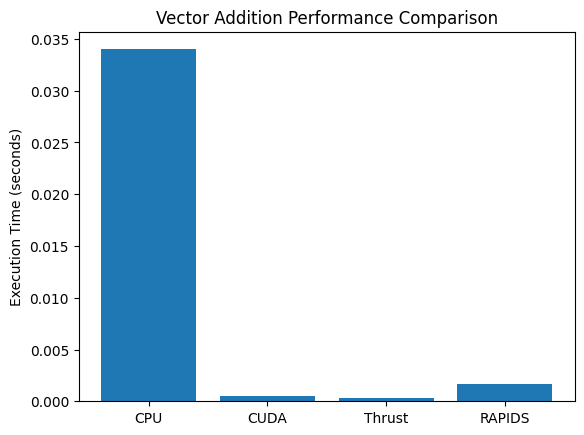

In [49]:
import matplotlib.pyplot as plt

methods = ["CPU","CUDA","Thrust","RAPIDS"]
times = [ 0.034,0.00048,0.00036,0.0017]

plt.bar(methods,times)
plt.ylabel("Execution Time (seconds)")
plt.title("Vector Addition Performance Comparison")
plt.show()

Q6 — Sum of Vector using Thrust

In [50]:
%%writefile thrust_sum.cu
#include <thrust/device_vector.h>
#include <thrust/reduce.h>
#include <iostream>

int main(){

    thrust::device_vector<int> vec(10);

    for(int i=0;i<10;i++)
        vec[i]=i+1;

    int sum = thrust::reduce(vec.begin(),vec.end());

    std::cout<<"Sum = "<<sum<<std::endl;
}

Writing thrust_sum.cu


In [51]:
!nvcc -arch=sm_75 thrust_sum.cu -o thrust_sum
!./thrust_sum

Sum = 55


Q7 — Thrust GPU Sorting

In [53]:
%%writefile thrust_sort.cu
#include <thrust/device_vector.h>
#include <thrust/sort.h>
#include <iostream>

int main(){

    int arr[8]={7,2,9,1,5,3,8,4};

    thrust::device_vector<int> vec(arr,arr+8);

    std::cout<<"Before Sorting:\n";

    for(int i=0;i<8;i++)
        std::cout<<vec[i]<<" ";

    thrust::sort(vec.begin(),vec.end());

    std::cout<<"\nAfter Sorting:\n";

    for(int i=0;i<8;i++)
        std::cout<<vec[i]<<" ";
}

Writing thrust_sort.cu


In [54]:
!nvcc -arch=sm_75 thrust_sort.cu -o thrust_sort
!./thrust_sort

Before Sorting:
7 2 9 1 5 3 8 4 
After Sorting:
1 2 3 4 5 7 8 9 